
  
**Title:** `Energy Production vs CO₂ Emissions`     
  
**Description:** `This notebook reproduces all empirical results presented.`    


# Energy Production vs CO₂ Emissions – Data Preparation & Methodology

This notebook documents **all data preparation steps** for the project:

> **Research question:**  
> *How do fossil, renewable, and nuclear energy production influence CO₂ emissions in the world’s top energy-producing, emitting, and most populous countries?*

The code and explanations here are designed to:
- Make the workflow **reproducible**
- Explicitly document **all difficulties and barriers** faced
- Justify each **methodological choice** based on data and context

We start from raw data files (EIA + World Bank) and end with a clean panel dataset ready for analysis.


In [1]:
# Install required libraries
!pip install pandas numpy statsmodels seaborn matplotlib
import pandas as pd
import numpy as np


## 1. File Paths and Data Sources

We use the following raw data sources:

**EIA (U.S. Energy Information Administration)**
- `EnergyProduction_World_1980_2023.csv` – total and disaggregated energy production
- `Emissions_World_1980_2023.csv` – total and disaggregated CO₂ emissions
- `INT-Export-12-07-2025_23-00-32.csv` – energy intensity (per capita, per GDP)

**World Bank**
- Population (SP.POP.TOTL): `Population_World_1980_2024.csv` (or similar naming)
- GDP (NY.GDP.MKTP.CD): `API_NY.GDP.MKTP.CD_DS2_en_csv_v2_2463.csv` (or similar)

> ⚠️ Adjust the file names below if your local files differ.


In [2]:
# Adjust these paths if your local filenames differ
RAW_ENERGY_PATH   = "dataset/EnergyProduction_World_1980_2023.csv"
RAW_EMISS_PATH    = "dataset/Emissions_World_1980_2023.csv"
RAW_INTEN_PATH    = "dataset/INT-Export-12-07-2025_23-00-32.csv"
RAW_POP_PATH      = "dataset/Population_World_1980_2024.csv"  # World Bank population
RAW_GDP_PATH      = "dataset/API_NY.GDP.MKTP.CD_DS2_en_csv_v2_2463.csv"  # World Bank GDP

CLEAN_ENERGY_PATH = "dataset/EnergyProduction_World_Cleaned_Region_Year.csv"
CLEAN_EMISS_PATH  = "dataset/Emissions_World_Cleaned_Region_Year.csv"
CLEAN_INTEN_PATH  = "dataset/EnergyIntensity_World_Cleaned_Region_Year.csv"
CLEAN_POP_PATH    = "dataset/Population_WorldBank_Cleaned_Region_Year.csv"
CLEAN_GDP_PATH    = "dataset/GDP_World_Cleaned_Region_Year.csv"


## 2. Cleaning EIA Energy Production Data

**Barrier:**  
The EIA energy file is **not** a simple table. It contains:

- Multiple metric blocks (e.g. total, coal, gas, petroleum, nuclear, renewables)
- Metric headers on rows where `API` is `NaN`
- Metric names in the `Unnamed: 1` column
- Year values across many columns (1980–2023)

**Resolution:**  
We write a custom parser that:

1. Reads the file and identifies header rows where `API` is `NaN`
2. Treats each block between header rows as one metric
3. Builds a long table with columns: `region`, `year`, `metric_value`
4. Pivots to wide format so that each row is `(region, year)` with multiple metric columns


In [3]:
def clean_energy_file(input_path: str, output_path: str):
    """
    Clean EIA energy production file into a panel:
    region, year, and energy production metrics.

    Difficulties handled:
    - Multiple metric blocks (API is NaN on metric header rows)
    - Metric names stored in `Unnamed: 1`
    - Year columns from 1980 to 2023
    """
    # Skip the first 'Report generated on:' row if present
    df = pd.read_csv(input_path, skiprows=[0])

    # Rows where a new metric starts: API is NaN
    header_idx = df[df["API"].isna()].index.tolist()

    # Map header row index to metric name (from 'Unnamed: 1')
    metric_names = {
        idx: str(df.loc[idx, "Unnamed: 1"]).strip()
        for idx in header_idx
    }

    years = [str(y) for y in range(1980, 2024)]
    records = []
    sorted_headers = sorted(header_idx)

    # Iterate over each metric block
    for i, start in enumerate(sorted_headers):
        metric_name = metric_names[start]
        end = sorted_headers[i + 1] if i + 1 < len(sorted_headers) else len(df)
        block = df.iloc[start + 1:end]

        for _, row in block.iterrows():
            region = str(row["Unnamed: 1"]).strip()
            if not region or region.lower() == "nan":
                continue
            for y in years:
                value = row.get(y, np.nan)
                records.append({
                    "region": region,
                    "year": int(y),
                    metric_name: value
                })

    long_df = pd.DataFrame(records)

    # Pivot to wide: one row per (region, year), one column per metric
    final_df = (
        long_df
        .pivot_table(index=["region", "year"], aggfunc="first")
        .reset_index()
    )

    # Standardize metric names to simple forms used in the project
    rename_map = {
        "total energy production (quad Btu)": "total energy production",
        "total energy production from coal (quad Btu)": "total energy production from coal",
        "total energy production from natural gas (quad Btu)": "total energy production from natural gas",
        "total energy production from petroleum and other liquids (quad Btu)": "total energy production from petroleum and other liquids",
        "total energy production from nuclear, renewables, and other (quad Btu)": "total energy production from nuclear, renewables and other",
        "total energy production from nuclear (quad Btu)": "total energy production from nuclear",
        "total energy production from renewables and other (quad Btu)": "total energy production from renewables and other",
    }

    final_df = final_df.rename(columns=rename_map)

    cols_order = [
        "region",
        "year",
        "total energy production",
        "total energy production from coal",
        "total energy production from natural gas",
        "total energy production from petroleum and other liquids",
        "total energy production from nuclear, renewables and other",
        "total energy production from nuclear",
        "total energy production from renewables and other",
    ]

    # Some older metrics may not exist in all files; use intersection
    cols_order = [c for c in cols_order if c in final_df.columns]

    final_df = (
        final_df[cols_order]
        .sort_values(["region", "year"])
        .reset_index(drop=True)
    )

    final_df.to_csv(output_path, index=False)
    print(f"Saved cleaned energy file to: {output_path}")
    return final_df

# Example call (uncomment when you want to run cleaning from raw):
clean_energy_file(RAW_ENERGY_PATH, CLEAN_ENERGY_PATH)

Saved cleaned energy file to: EnergyProduction_World_Cleaned_Region_Year.csv


,region,year,total energy production,total energy production from coal,total energy production from natural gas,total energy production from petroleum and other liquids,"total energy production from nuclear, renewables and other",total energy production from nuclear,total energy production from renewables and other
0,Afghanistan,1980,0.06760131850863463,0.0023552858074806604,0.06282,0,0.0024260327011539655,0,0.0024260327011539655
1,Afghanistan,1981,0.08764719386592894,0.0024740397484436876,0.082713,0,0.0024601541174852446,0,0.0024601541174852446
2,Afghanistan,1982,0.09008927029309094,0.002869886158469484,0.084807,0,0.0024123841346214534,0,0.0024123841346214534
3,Afghanistan,1983,0.09441034381678293,0.002869886158469484,0.088995,0,0.0025454576583134434,0,0.0025454576583134434
4,Afghanistan,1984,0.09450725425545241,0.0029292630391745574,0.088995,0,0.0025829912162778504,0,0.0025829912162778504
...,...,...,...,...,...,...,...,...,...
10159,Zimbabwe,2019,0.08187639776126848,0.06485249469195767,0,0,0.017023903069310814,0,0.017023903069310814
10160,Zimbabwe,2020,0.08073381036036813,0.06680088802465292,0,0,0.013932922335715197,0,0.013932922335715197
10161,Zimbabwe,2021,0.10305541872236652,0.0799658545131074,0,0,0.02308956420925911,0,0.02308956420925911
10162,Zimbabwe,2022,0.11209677923255594,0.08899642202957997,0,0,0.02310035720297597,0,0.02310035720297597


## 3. Cleaning EIA CO₂ Emissions Data

**Barrier:**  
The EIA CO₂ emissions file has the **same multi-block structure** as the energy file:
- Metric header rows where `API` is `NaN`
- Metric names in `Unnamed: 1`
- Year columns spread across many columns

**Resolution:**  
We reuse the same logic as for energy, but map emission-specific metric names.


In [4]:
def clean_emissions_file(input_path: str, output_path: str):
    """
    Clean EIA CO2 emissions file into:
    region, year, and CO2 metrics.

    Difficulties handled:
    - Multiple metric blocks indicated by `API`=NaN
    - Metric names in 'Unnamed: 1'
    """
    df = pd.read_csv(input_path, skiprows=[0])

    header_idx = df[df["API"].isna()].index.tolist()
    metric_names = {
        idx: str(df.loc[idx, "Unnamed: 1"]).strip()
        for idx in header_idx
    }

    years = [str(y) for y in range(1980, 2024)]
    records = []
    sorted_headers = sorted(header_idx)

    for i, start in enumerate(sorted_headers):
        metric_name = metric_names[start]
        end = sorted_headers[i + 1] if i + 1 < len(sorted_headers) else len(df)
        block = df.iloc[start + 1:end]

        for _, row in block.iterrows():
            region = str(row["Unnamed: 1"]).strip()
            if not region or region.lower() == "nan":
                continue
            for y in years:
                value = row.get(y, np.nan)
                records.append({
                    "region": region,
                    "year": int(y),
                    metric_name: value,
                })

    long_df = pd.DataFrame(records)

    final_df = (
        long_df
        .pivot_table(index=["region", "year"], aggfunc="first")
        .reset_index()
    )

    rename_map = {
        "CO2 emissions (MMtonnes CO2)": "CO2 emissions",
        "coal and coke CO2 emissions (MMtonnes CO2)": "coal and coke CO2 emissions",
        "consumed natural gas CO2 emissions (MMtonnes CO2)": "consumed natural gas CO2 emissions",
        "petroleum and other liquids CO2 emissions (MMtonnes CO2)": "petroleum and other liquids CO2 emissions",
    }

    final_df = final_df.rename(columns=rename_map)

    cols_order = [
        "region",
        "year",
        "CO2 emissions",
        "coal and coke CO2 emissions",
        "consumed natural gas CO2 emissions",
        "petroleum and other liquids CO2 emissions",
    ]
    cols_order = [c for c in cols_order if c in final_df.columns]

    final_df = (
        final_df[cols_order]
        .sort_values(["region", "year"])
        .reset_index(drop=True)
    )

    final_df.to_csv(output_path, index=False)
    print(f"Saved cleaned emissions file to: {output_path}")
    return final_df

# Example call:
clean_emissions_file(RAW_EMISS_PATH, CLEAN_EMISS_PATH)

Saved cleaned emissions file to: Emissions_World_Cleaned_Region_Year.csv


,region,year,CO2 emissions,coal and coke CO2 emissions,consumed natural gas CO2 emissions,petroleum and other liquids CO2 emissions
0,Afghanistan,1980,1.325964518,0.2313138584444692,0.11110066,0.98355
1,Afghanistan,1981,1.509627735,0.24297674547176684,0.16665099,1.1
2,Afghanistan,1982,1.65960468,0.2818530296847648,0.27775165,1.1
3,Afghanistan,1983,2.05960468,0.2818530296847648,0.27775165,1.5
4,Afghanistan,1984,2.065436114,0.28768446438142214,0.27775165,1.5
...,...,...,...,...,...,...
10156,Zimbabwe,2019,9.511751761,5.468512461117518,0,4.0432393
10157,Zimbabwe,2020,7.687652122,4.49168472239884,0,3.1959674
10158,Zimbabwe,2021,8.108754763,4.149746662939408,0,3.9590081
10159,Zimbabwe,2022,14.380703728,9.568461727838926,0,4.812242


## 4. Cleaning World Bank Population Data

**Barrier:**  
We initially tried to use EIA population exports, but they had a **non-tabular structure** (repeated year–value pairs in a single row).  
This made them extremely hard to parse reliably.

**Resolution:**  
We switched to the **World Bank** population file (SP.POP.TOTL), which has:

- A metadata header (first 4 rows)
- `Country Name` and year columns (1960–2024)
- Easy reshaping into a `region–year–population` panel.


In [5]:
def clean_population_worldbank(input_path: str, output_path: str):
    """
    Clean World Bank population CSV (SP.POP.TOTL) into long format:
    region, country_code, year, population.
    """
    df = pd.read_csv(input_path, skiprows=4)

    year_cols = [col for col in df.columns if col.isdigit()]
    use_cols = ["Country Name", "Country Code"] + year_cols
    df = df[use_cols]

    long_df = df.melt(
        id_vars=["Country Name", "Country Code"],
        var_name="year",
        value_name="population"
    )

    long_df = long_df.rename(
        columns={
            "Country Name": "region",
            "Country Code": "country_code",
        }
    )
    long_df["year"] = long_df["year"].astype(int)

    final_df = (
        long_df
        .sort_values(["region", "year"])
        .reset_index(drop=True)
    )

    final_df.to_csv(output_path, index=False)
    print(f"Saved cleaned population file to: {output_path}")
    return final_df

# Example call:
clean_population_worldbank(RAW_POP_PATH, CLEAN_POP_PATH)

Saved cleaned population file to: Population_WorldBank_Cleaned_Region_Year.csv


,region,country_code,year,population
0,Afghanistan,AFG,1960,9035043.0
1,Afghanistan,AFG,1961,9214083.0
2,Afghanistan,AFG,1962,9404406.0
3,Afghanistan,AFG,1963,9604487.0
4,Afghanistan,AFG,1964,9814318.0
...,...,...,...,...
17285,Zimbabwe,ZWE,2020,15526888.0
17286,Zimbabwe,ZWE,2021,15797210.0
17287,Zimbabwe,ZWE,2022,16069056.0
17288,Zimbabwe,ZWE,2023,16340822.0


## 5. Cleaning World Bank GDP Data

We use **GDP in current USD** (indicator `NY.GDP.MKTP.CD`).  
The structure is the same as for population: metadata rows + wide year columns.

We reshape to a `region–year–gdp` panel.


In [6]:
def clean_gdp_file(input_path: str, output_path: str):
    """
    Clean World Bank GDP CSV (NY.GDP.MKTP.CD) into:
    region, year, gdp.
    """
    df = pd.read_csv(input_path, skiprows=4)

    year_cols = [col for col in df.columns if col.isdigit()]
    use_cols = ["Country Name"] + year_cols
    df = df[use_cols]

    long_df = df.melt(
        id_vars=["Country Name"],
        var_name="year",
        value_name="gdp"
    )

    long_df = long_df.rename(columns={"Country Name": "region"})
    long_df["year"] = long_df["year"].astype(int)

    final_df = (
        long_df
        .sort_values(["region", "year"])
        .reset_index(drop=True)
    )

    final_df.to_csv(output_path, index=False)
    print(f"Saved cleaned GDP file to: {output_path}")
    return final_df

# Example call:
clean_gdp_file(RAW_GDP_PATH, CLEAN_GDP_PATH)

Saved cleaned GDP file to: GDP_World_Cleaned_Region_Year.csv


,region,year,gdp
0,Afghanistan,1960,NaN
1,Afghanistan,1961,NaN
2,Afghanistan,1962,NaN
3,Afghanistan,1963,NaN
4,Afghanistan,1964,NaN
...,...,...,...
17285,Zimbabwe,2020,2.686856e+10
17286,Zimbabwe,2021,2.724051e+10
17287,Zimbabwe,2022,3.278966e+10
17288,Zimbabwe,2023,3.523137e+10


## 6. Cleaning EIA Energy Intensity Data

**Barriers:**  

- The file `INT-Export-12-07-2025_23-00-32.csv` has:
  - The header on the **second row** → we must use `header=1`
  - Two metric blocks:
    - *energy consumption per capita (MMBtu/person)*
    - *energy consumption per GDP (1000 Btu per 2015 USD)*
  - Metric headers indicated by `API` = `NaN`

**Resolution:**  
We:

1. Read with `header=1`
2. Use `API` = `NaN` rows to detect block boundaries
3. Build long format and pivot to wide with:
   - `energy_per_capita`
   - `energy_per_gdp`


In [7]:
def clean_intensity_file(input_path: str, output_path: str):
    """
    Clean EIA energy intensity file into:
    region, year, energy_per_capita, energy_per_gdp.
    """
    df = pd.read_csv(input_path, header=1)

    header_idx = df[df["API"].isna()].index.tolist()
    metric_names = {
        idx: str(df.loc[idx, "Unnamed: 1"]).strip()
        for idx in header_idx
    }

    year_cols = [c for c in df.columns if c.isdigit()]
    years = [y for y in year_cols if 1980 <= int(y) <= 2023]

    records = []
    sorted_headers = sorted(header_idx)

    for i, start in enumerate(sorted_headers):
        metric_name = metric_names[start]
        end = sorted_headers[i + 1] if i + 1 < len(sorted_headers) else len(df)
        block = df.iloc[start + 1:end]

        for _, row in block.iterrows():
            region = str(row["Unnamed: 1"]).strip()
            if not region or region.lower() == "nan":
                continue
            for y in years:
                value = row.get(y, np.nan)
                records.append({
                    "region": region,
                    "year": int(y),
                    metric_name: value
                })

    long_df = pd.DataFrame(records)

    wide = (
        long_df
        .pivot_table(index=["region", "year"], aggfunc="first")
        .reset_index()
    )

    rename_map = {
        "energy consumption per capita (MMBtu/person)": "energy_per_capita",
        "energy consumption per GDP (1000 Btu/2015$ GDP PPP)": "energy_per_gdp",
        "energy consumption per GDP (1000 Btu per 2015 U.S. dollar)": "energy_per_gdp",
    }
    wide = wide.rename(columns=rename_map)

    wide.to_csv(output_path, index=False)
    print(f"Saved cleaned intensity file to: {output_path}")
    return wide

# Example call:
clean_intensity_file(RAW_INTEN_PATH, CLEAN_INTEN_PATH)

Saved cleaned intensity file to: EnergyIntensity_World_Cleaned_Region_Year.csv


,region,year,energy_per_gdp,energy_per_capita
0,Afghanistan,1980,0,1.6419523148536865
1,Afghanistan,1981,0,2.0835878672485553
2,Afghanistan,1982,0,2.4491208142216907
3,Afghanistan,1983,0,3.08842177882219
4,Afghanistan,1984,0,3.0278360584640804
...,...,...,...,...
9937,Zimbabwe,2019,3.164076251244071,8.88481583508217
9938,Zimbabwe,2020,2.899289165319292,7.380693563183577
9939,Zimbabwe,2021,2.9955192198452507,8.129208107667864
9940,Zimbabwe,2022,4.378325639150368,12.396541500930178


## 7. Restricting to 1991–2023 (First Time Window)

**Barrier:**  
Pre-1990 data is affected by:

- Historical entities (Former U.S.S.R., Former Yugoslavia, East/West Germany)
- Many GDP gaps
- Non-comparable country definitions

**Resolution:**  
For stability and comparability, we first restrict all datasets to **1991–2023**.
Later, after detecting exactly which rows are missing, we further refine to **1992–2023** based on evidence (Russia & Kazakhstan).


In [8]:
# Filter cleaned files to 1991–2023 and save intermediate copies
files = {
    "energy": CLEAN_ENERGY_PATH,
    "emiss":  CLEAN_EMISS_PATH,
    "inten":  CLEAN_INTEN_PATH,
    "gdp":    CLEAN_GDP_PATH,
    "pop":    CLEAN_POP_PATH,
}

def filter_from_1991(df):
    df["year"] = df["year"].astype(int)
    return df[df["year"] >= 1991].reset_index(drop=True)

for key, fname in files.items():
    df = pd.read_csv(fname)
    df = filter_from_1991(df)
    df.to_csv(f"dataset/{key}_1991_2023.csv", index=False)
    print(f"Saved {key}_1991_2023.csv with shape {df.shape}")

Saved energy_1991_2023.csv with shape (7623, 9)
Saved emiss_1991_2023.csv with shape (7620, 6)
Saved inten_1991_2023.csv with shape (7456, 4)
Saved gdp_1991_2023.csv with shape (9044, 3)
Saved pop_1991_2023.csv with shape (9044, 4)


## 8. Load 1991–2023 Datasets, Harmonize Names and Types

**Barriers encountered:**
- World Bank uses `Iran, Islamic Rep.`, `Russian Federation`, `Korea, Rep.`  
  while EIA uses `Iran`, `Russia`, `South Korea`.
- Some numeric columns were read as text, causing errors in `.mean()` etc.

**Resolutions:**
- Apply a consistent country name mapping for GDP and population.
- Use `pd.to_numeric(..., errors='coerce')` to ensure numeric types.


In [9]:
# Load filtered 1991–2023 files
energy = pd.read_csv("dataset/energy_1991_2023.csv")
emiss  = pd.read_csv("dataset/emiss_1991_2023.csv")
gdp    = pd.read_csv("dataset/gdp_1991_2023.csv")
inten  = pd.read_csv("dataset/inten_1991_2023.csv")
pop    = pd.read_csv("dataset/pop_1991_2023.csv")

for df in [energy, emiss, gdp, inten, pop]:
    df["region"] = df["region"].astype(str).str.strip()
    df["year"]   = df["year"].astype(int)

# World Bank → standard country name mapping
wb_to_standard = {
    "Iran, Islamic Rep.": "Iran",
    "Russian Federation": "Russia",
    "Korea, Rep.": "South Korea",
}
gdp["region"] = gdp["region"].replace(wb_to_standard)
pop["region"] = pop["region"].replace(wb_to_standard)

# Ensure numeric for key columns
energy_num_cols = [c for c in energy.columns if c not in ["region", "year"]]
energy[energy_num_cols] = energy[energy_num_cols].apply(pd.to_numeric, errors="coerce")

emiss_num_cols = [c for c in emiss.columns if c not in ["region", "year"]]
emiss[emiss_num_cols] = emiss[emiss_num_cols].apply(pd.to_numeric, errors="coerce")

if "gdp" in gdp.columns:
    gdp["gdp"] = pd.to_numeric(gdp["gdp"], errors="coerce")

pop["population"] = pd.to_numeric(pop["population"], errors="coerce")

inten_num_cols = [c for c in inten.columns if c not in ["region", "year"]]
inten[inten_num_cols] = inten[inten_num_cols].apply(pd.to_numeric, errors="coerce")

## 9. Selecting Countries: Top 20 Energy, Top 20 CO₂ , Top 20 Population

**Initial barrier:**  
When we took the Top 20 population from World Bank **without filtering**, we got aggregates like:
- `World`
- `IDA & IBRD total`
- `OECD members`
- `Sub-Saharan Africa`

These are **not countries**, and including them would destroy the quality of the panel.

**Resolution:**  
1. Define a **country universe** from the EIA energy dataset (all `region` values except `World`).  
2. Filter population and emissions to this universe.  
3. Compute:
   - Top 20 energy producers (2019–2023 average)
   - Top 20 CO₂ emitters (2019–2023 average)
   - Top 20 population countries (2019–2023 average)
4. Take the **union** of the three lists → final analysis set (33 countries).


In [10]:
# 1) Define country universe from energy (exclude World)
country_universe = sorted(energy["region"].unique())
# country_universe = [c for c in country_universe if c != "World"]

energy_c = energy[energy["region"].isin(country_universe)]
emiss_c  = emiss[emiss["region"].isin(country_universe)]
pop_c    = pop[pop["region"].isin(country_universe)]

# Use last 5 years (2019–2023) as stable current period
energy_recent = energy_c[energy_c["year"].between(2019, 2023)]
emiss_recent  = emiss_c[emiss_c["year"].between(2019, 2023)]
pop_recent    = pop_c[pop_c["year"].between(2019, 2023)]

top20_energy = (
    energy_recent.groupby("region")["total energy production"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
    .index.tolist()
)

top20_co2 = (
    emiss_recent.groupby("region")["CO2 emissions"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
    .index.tolist()
)

top20_pop = (
    pop_recent.groupby("region")["population"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
    .index.tolist()
)

print("Top 20 energy (countries only):", top20_energy)
print("Top 20 CO2   (countries only):", top20_co2)
print("Top 20 pop   (countries only):", top20_pop)

final_countries = sorted(set(top20_energy) | set(top20_co2) | set(top20_pop))
print("\nFinal country set (union, countries only):")
print(final_countries)
print("Total countries in union:", len(final_countries))

Top 20 energy (countries only): ['World', 'China', 'United States', 'Russia', 'Saudi Arabia', 'Canada', 'India', 'Australia', 'Indonesia', 'Iran', 'Brazil', 'United Arab Emirates', 'Qatar', 'Iraq', 'Norway', 'Kazakhstan', 'Kuwait', 'Algeria', 'Mexico', 'South Africa']
Top 20 CO2   (countries only): ['World', 'China', 'United States', 'India', 'Russia', 'Japan', 'Iran', 'Germany', 'Indonesia', 'South Korea', 'Saudi Arabia', 'Canada', 'South Africa', 'Mexico', 'Brazil', 'Australia', 'Turkiye', 'United Kingdom', 'Italy', 'France']
Top 20 pop   (countries only): ['World', 'India', 'China', 'United States', 'Indonesia', 'Pakistan', 'Nigeria', 'Brazil', 'Bangladesh', 'Russia', 'Mexico', 'Japan', 'Ethiopia', 'Philippines', 'Iran', 'Turkiye', 'Germany', 'Thailand', 'France', 'United Kingdom']

Final country set (union, countries only):
['Algeria', 'Australia', 'Bangladesh', 'Brazil', 'Canada', 'China', 'Ethiopia', 'France', 'Germany', 'India', 'Indonesia', 'Iran', 'Iraq', 'Italy', 'Japan', 'Ka

## 10. Compatibility Check: Are All 33 Countries Present in Each Dataset?

We now verify that **every country in `final_countries`** appears in:

- `energy_1991_2023.csv`
- `emiss_1991_2023.csv`
- `gdp_1991_2023.csv`
- `pop_1991_2023.csv`
- `inten_1991_2023.csv`

After fixing the World Bank name mapping, the check should show **no missing countries**.


In [11]:
datasets = {
    "energy": energy,
    "emiss":  emiss,
    "gdp":    gdp,
    "pop":    pop,
    "inten":  inten,
}

for name, df in datasets.items():
    present = set(df["region"].unique())
    missing = [c for c in final_countries if c not in present]
    print(f"\nMissing in {name}: {missing}")


Missing in energy: []

Missing in emiss: []

Missing in gdp: []

Missing in pop: []

Missing in inten: []


## 11. Merging Datasets into a Single Panel (1991–2023, 33 Countries)

We now:

1. Filter each dataset to the 33 final countries.
2. Merge on `region` + `year` (outer logic controlled by starting from energy).  
3. Inspect missing values to understand structural data issues.


In [12]:
# Filter to final_countries only
energy_sel = energy[energy["region"].isin(final_countries)]
emiss_sel  = emiss[emiss["region"].isin(final_countries)]
gdp_sel    = gdp[gdp["region"].isin(final_countries)]
pop_sel    = pop[pop["region"].isin(final_countries)]
inten_sel  = inten[inten["region"].isin(final_countries)]

# Merge step by step
panel = energy_sel.copy()

panel = panel.merge(
    emiss_sel,
    on=["region", "year"],
    how="left",
    suffixes=("", "_emiss")
)

panel = panel.merge(
    pop_sel[["region", "year", "population"]],
    on=["region", "year"],
    how="left"
)

panel = panel.merge(
    gdp_sel[["region", "year", "gdp"]],
    on=["region", "year"],
    how="left"
)

panel = panel.merge(
    inten_sel,
    on=["region", "year"],
    how="left",
    suffixes=("", "_inten")
)

panel = panel.sort_values(["region", "year"]).reset_index(drop=True)

print(panel.head())
print("\nShape:", panel.shape)

print("\nNA counts (main columns):")
print(
    panel[[
        "region", "year",
        "total energy production",
        "CO2 emissions",
        "population",
        "gdp",
        "energy_per_capita",
        "energy_per_gdp",
    ]].isna().sum()
)

    region  year  total energy production  total energy production from coal  \
0  Algeria  1991                 4.862839                           0.000316   
1  Algeria  1992                 4.902583                           0.000380   
2  Algeria  1993                 4.803771                           0.000506   
3  Algeria  1994                 4.647497                           0.000582   
4  Algeria  1995                 4.967690                           0.000557   

   total energy production from natural gas  \
0                                  2.280940   
1                                  2.325281   
2                                  2.244438   
3                                  2.131930   
4                                  2.421124   

   total energy production from petroleum and other liquids  \
0                                           2.580594          
1                                           2.576251          
2                                           2.5

### 11.1. Identify Exactly Which Rows Have Missing Values

Instead of assuming which countries/years are missing, we **detect them directly** from the panel.


In [13]:
missing_rows = panel[panel.isna().any(axis=1)].sort_values(["year", "region"])
missing_rows

,region,year,total energy production,total energy production from coal,total energy production from natural gas,total energy production from petroleum and other liquids,"total energy production from nuclear, renewables and other",total energy production from nuclear,total energy production from renewables and other,CO2 emissions,coal and coke CO2 emissions,consumed natural gas CO2 emissions,petroleum and other liquids CO2 emissions,population,gdp,energy_per_gdp,energy_per_capita
495,Kazakhstan,1991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17278600.0,2.492308e+10,NaN,NaN
759,Russia,1991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,148394216.0,5.179630e+11,NaN,NaN
230,Ethiopia,2023,0.073464,0.011143,0.0,0.0,0.062321,0.0,0.062321,18.518765,3.426765,0.0,15.092,128691692.0,NaN,0.970256,2.365846


## 12. Interpreting Missing Rows and Final Time Window Choice

From the `missing_rows` output, we observed that:

- **Kazakhstan, 1991** – all energy and CO₂-related variables are missing
- **Russia, 1991** – all energy and CO₂-related variables are missing
- **Ethiopia, 2023** – only **GDP** is missing; energy, emissions, and population exist

**Interpretation:**

- Kazakhstan and Russia are former Soviet republics. In 1991, they were still part of the **Soviet Union**, and country-level EIA data is not reported for that year.
- Therefore, 1991 is structurally incomplete for these two key countries.

**Methodological decision:**  
To avoid biased or inconsistent analysis:

> We **set the analysis period to 1992–2023**.

Ethiopia’s single missing GDP value in 2023 is treated separately (see next step).


In [14]:
# Filter panel to 1992–2023 based on evidence (Russia & Kazakhstan missing 1991)
panel = panel[panel["year"] >= 1992].reset_index(drop=True)
print("Panel shape after restricting to 1992–2023:", panel.shape)

Panel shape after restricting to 1992–2023: (1056, 17)


## 13. Handling Ethiopia's Single Missing GDP Value (2023) via Interpolation

**Barrier:**  
Ethiopia is a major population country and important for the study, but **GDP in 2023 is missing**.

- Energy variables: present
- CO₂ variables: present
- Population: present
- Only GDP: NaN (one observation)

Dropping Ethiopia entirely would be disproportionate and unnecessary.

**Resolution:**  
We keep Ethiopia and fill the single missing GDP value using **linear interpolation** within Ethiopia's GDP time series.

This is standard practice in empirical economics and is easy to explain in the methodology section.


In [15]:
# Sort for time-series operations
panel = panel.sort_values(["region", "year"]).reset_index(drop=True)

# Interpolate GDP within each country
panel["gdp"] = panel.groupby("region")["gdp"].transform(
    lambda x: x.interpolate(method="linear")
)

# Check Ethiopia tail to confirm interpolation
panel[panel["region"] == "Ethiopia"].tail()

,region,year,total energy production,total energy production from coal,total energy production from natural gas,total energy production from petroleum and other liquids,"total energy production from nuclear, renewables and other",total energy production from nuclear,total energy production from renewables and other,CO2 emissions,coal and coke CO2 emissions,consumed natural gas CO2 emissions,petroleum and other liquids CO2 emissions,population,gdp,energy_per_gdp,energy_per_capita
219,Ethiopia,2019,0.052378,0.000000,0.0,0.0,0.052378,0.0,0.052378,16.470025,1.278047,0.0,15.191978,115737383.0,9.591262e+10,1.089476,2.348329
220,Ethiopia,2020,0.053412,0.000000,0.0,0.0,0.053412,0.0,0.053412,13.756569,1.127119,0.0,12.629450,118917671.0,1.076577e+11,0.884564,1.968100
221,Ethiopia,2021,0.053933,0.000000,0.0,0.0,0.053933,0.0,0.053933,14.389297,0.985727,0.0,13.403571,122138588.0,1.112619e+11,0.872418,1.996506
222,Ethiopia,2022,0.059626,0.000196,0.0,0.0,0.059431,0.0,0.059431,16.294497,1.439969,0.0,14.854528,125384287.0,1.267727e+11,0.933564,2.191885
223,Ethiopia,2023,0.073464,0.011143,0.0,0.0,0.062321,0.0,0.062321,18.518765,3.426765,0.0,15.092000,128691692.0,1.267727e+11,0.970256,2.365846


## 14. Save Final Panel Dataset

At this point, we have:

- A **33-country** panel
- Years **1992–2023**
- Harmonized names and numeric types
- Energy, CO₂, population, GDP, and energy intensity
- Missing values only where structurally unavoidable (and handled explicitly)

We now save this final dataset for EDA and regression.


In [16]:
panel.to_csv("dataset/panel_33countries_1992_2023.csv", index=False)
print("Final panel saved as 'panel_33countries_1992_2023.csv' with shape:", panel.shape)

Final panel saved as 'panel_33countries_1992_2023.csv' with shape: (1056, 17)


In [17]:
df = pd.read_csv("dataset/panel_33countries_1992_2023.csv")

# Log variables
df["ln_co2"] = np.log(df["CO2 emissions"])
df["ln_gdp"] = np.log(df["gdp"])
df["ln_population"] = np.log(df["population"])
df["ln_total_energy"] = np.log(df["total energy production"])
df["ln_fossil_energy"] = np.log(
    df["total energy production from coal"]
    + df["total energy production from natural gas"]
    + df["total energy production from petroleum and other liquids"]
)

# Energy shares
df["renewables_share"] = (
    df["total energy production from renewables and other"]
    / df["total energy production"]
)

df["nuclear_share"] = (
    df["total energy production from nuclear"]
    / df["total energy production"]
)

# Per-capita & intensity indicators
df["energy_per_capita"] = df["total energy production"] / df["population"]
df["energy_per_gdp"] = df["total energy production"] / df["gdp"]
df.to_csv("dataset/panel_33countries_1992_2023_features.csv", index=False)


C:\Users\Kamal_FOM\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [18]:
import numpy as np
import pandas as pd

# =========================================================
# Load final clean panel
# =========================================================
df = pd.read_csv("dataset/panel_33countries_1992_2023.csv")

# =========================================================
# Energy aggregates
# =========================================================
df["fossil_energy"] = (
    df["total energy production from coal"]
    + df["total energy production from natural gas"]
    + df["total energy production from petroleum and other liquids"]
)

df["renewables_energy"] = df["total energy production from renewables and other"]
df["nuclear_energy"] = df["total energy production from nuclear"]

# =========================================================
# Log variables (scale effects)
# =========================================================
df["ln_co2"] = np.where(df["CO2 emissions"] > 0, np.log(df["CO2 emissions"]), np.nan)
df["ln_gdp"] = np.where(df["gdp"] > 0, np.log(df["gdp"]), np.nan)
df["ln_population"] = np.where(df["population"] > 0, np.log(df["population"]), np.nan)
df["ln_total_energy"] = np.where(df["total energy production"] > 0,
                                 np.log(df["total energy production"]), np.nan)

df["ln_fossil_energy"] = np.where(df["fossil_energy"] > 0,
                                  np.log(df["fossil_energy"]), np.nan)

df["ln_renewables_energy"] = np.where(df["renewables_energy"] > 0,
                                      np.log(df["renewables_energy"]), np.nan)

df["ln_nuclear_energy"] = np.where(df["nuclear_energy"] > 0,
                                   np.log(df["nuclear_energy"]), np.nan)

# =========================================================
# Energy shares (composition effects)
# =========================================================
total_energy = df["total energy production"]

df["fossil_share"] = np.where(total_energy > 0, df["fossil_energy"] / total_energy, np.nan)
df["renewables_share"] = np.where(total_energy > 0, df["renewables_energy"] / total_energy, np.nan)
df["nuclear_share"] = np.where(total_energy > 0, df["nuclear_energy"] / total_energy, np.nan)

# =========================================================
# Intensity & per-capita indicators
# =========================================================
df["co2_per_capita"] = np.where(df["population"] > 0,
                                df["CO2 emissions"] / df["population"], np.nan)

df["co2_per_energy"] = np.where(df["total energy production"] > 0,
                                df["CO2 emissions"] / df["total energy production"], np.nan)

df["energy_per_capita"] = np.where(df["population"] > 0,
                                   df["total energy production"] / df["population"], np.nan)

df["energy_per_gdp"] = np.where(df["gdp"] > 0,
                                df["total energy production"] / df["gdp"], np.nan)

# =========================================================
# Save FINAL feature dataset
# =========================================================
df.to_csv("dataset/panel_33countries_1992_2023_features.csv", index=False)

print("✅ Final feature file created: panel_33countries_1992_2023_features.csv")


✅ Final feature file created: panel_33countries_1992_2023_features.csv


C:\Users\Kamal_FOM\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\Kamal_FOM\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\Kamal_FOM\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\Kamal_FOM\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


---

## 15. Next Steps (Beyond This Notebook)

From here, the next typical steps are:

1. **Create analytical variables**  
   - Fossil energy (coal + gas + petroleum)
   - Nuclear and renewables
   - Shares of each in total energy
   - Log-transformed variables (log CO₂, log GDP, log population)

2. **Descriptive analysis (EDA)**  
   - Time trends by country and globally
   - Correlations between energy mix and CO₂
   - Comparison across country groups

3. **Econometric modelling**  
   - Fixed-effects panel regression
   - Robustness checks (e.g. alternative time windows, excluding outliers)
   - Interpretation of coefficients in the context of climate and energy policy

All of these steps will reference this notebook as the **data preparation and methodology backbone**, documenting every barrier and the reasoning behind each choice.


## 16. Exploratory Data Analysis (EDA)

After constructing and cleaning the panel dataset, this section explores the data to:

- check that the merged series behave plausibly,
- describe global and country-level patterns in energy production and CO₂ emissions, and
- motivate the choice of log–log panel regressions with both scale (levels) and composition (shares) variables.

The EDA proceeds in two steps. First, the EIA **World** aggregate is used purely for **contextual global trends**. Second, the analysis focuses strictly on the **country-level panel**, which forms the empirical basis for the regression models. The World series is *never* treated as a country in the econometric analysis.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

panel = pd.read_csv("dataset/panel_33countries_1992_2023_features.csv")

# Explicit split: World vs countries
world = panel[panel["region"] == "World"].sort_values("year").copy()
countries = panel[panel["region"] != "World"].sort_values(["region", "year"]).copy()

print("Rows total:", panel.shape[0])
print("Rows World:", world.shape[0])
print("Rows countries:", countries.shape[0])
print("Years World:", world["year"].min(), "–", world["year"].max())


Rows total: 1056
Rows World: 32
Rows countries: 1024
Years World: 1992 – 2023


In [20]:
panel.columns

Index(['region', 'year', 'total energy production',
       'total energy production from coal',
       'total energy production from natural gas',
       'total energy production from petroleum and other liquids',
       'total energy production from nuclear, renewables and other',
       'total energy production from nuclear',
       'total energy production from renewables and other', 'CO2 emissions',
       'coal and coke CO2 emissions', 'consumed natural gas CO2 emissions',
       'petroleum and other liquids CO2 emissions', 'population', 'gdp',
       'energy_per_gdp', 'energy_per_capita', 'fossil_energy',
       'renewables_energy', 'nuclear_energy', 'ln_co2', 'ln_gdp',
       'ln_population', 'ln_total_energy', 'ln_fossil_energy',
       'ln_renewables_energy', 'ln_nuclear_energy', 'fossil_share',
       'renewables_share', 'nuclear_share', 'co2_per_capita',
       'co2_per_energy'],
      dtype='object')

In [21]:
panel.sample(5)

,region,year,total energy production,total energy production from coal,total energy production from natural gas,total energy production from petroleum and other liquids,"total energy production from nuclear, renewables and other",total energy production from nuclear,total energy production from renewables and other,CO2 emissions,...,ln_population,ln_total_energy,ln_fossil_energy,ln_renewables_energy,ln_nuclear_energy,fossil_share,renewables_share,nuclear_share,co2_per_capita,co2_per_energy
708,Qatar,1996,1.650361,0.000000,0.506555,1.143807,0.000000,0.00000,0.000000,30.976111,...,13.178780,0.500994,0.500994,NaN,NaN,1.000000,0.000000,0.000000,0.000059,18.769290
381,Iran,2021,16.838853,0.045829,9.535615,7.177189,0.080220,0.03346,0.046760,711.842386,...,18.298010,2.823689,2.818914,-3.062717,-3.397415,0.995236,0.002777,0.001987,0.000008,42.273805
48,Australia,2008,11.363395,8.693197,1.516708,1.052119,0.101370,0.00000,0.101370,384.545755,...,16.871830,2.430397,2.421436,-2.288973,NaN,0.991079,0.008921,0.000000,0.000018,33.840746
55,Australia,2015,15.478536,12.094638,2.503117,0.732702,0.148079,0.00000,0.148079,382.012325,...,16.985868,2.739454,2.729842,-1.910007,NaN,0.990433,0.009567,0.000000,0.000016,24.680132
258,Germany,1994,5.873661,3.511720,0.629167,0.124936,1.607837,1.46109,0.146747,911.072921,...,18.215357,1.770478,1.450635,-1.919043,0.379183,0.726263,0.024984,0.248753,0.000011,155.111589


### 16.1 Global context: World energy and CO₂ trends

The following cell prepares a comparison between:

- the EIA **World** aggregate for total energy production and CO₂ emissions, and
- the **average across the 33-country sample** for the same variables.

Both series are indexed to a common base year to show relative growth. This provides a macro-level picture of how fast global energy use and emissions have grown compared to a typical country in the sample. These plots are descriptive only and are not used in the regression analysis.

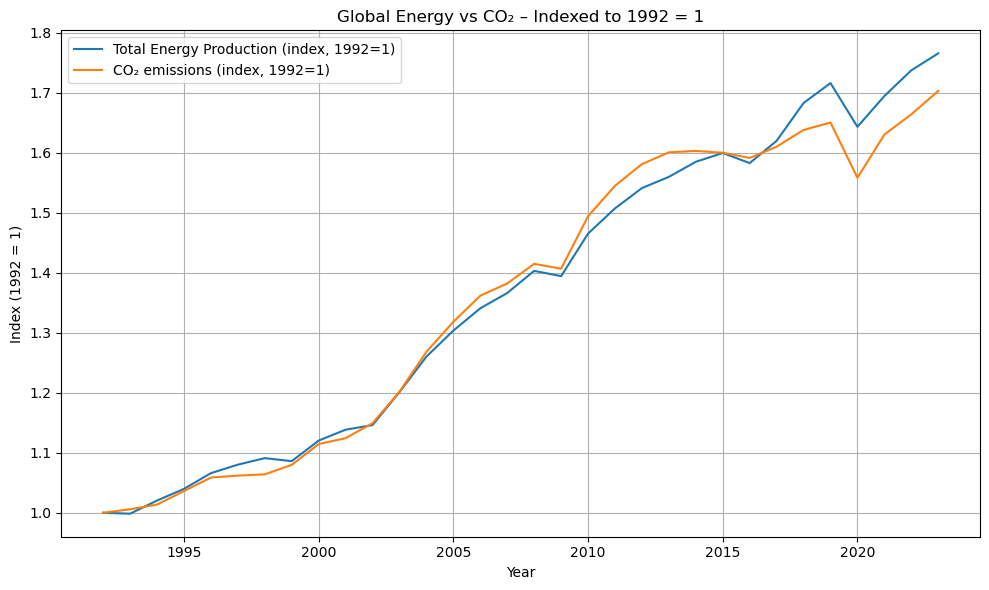

In [22]:
# Make sure column names are clean
world.columns = [c.strip() for c in world.columns]

# Convenience aliases
col_total = "total energy production"
col_co2   = "CO2 emissions"

w = world.set_index("year")[[col_total, col_co2]].copy()

base_year = 1992
base = w.loc[base_year]

norm = w / base  # each series divided by its 1992 value

plt.figure()
plt.plot(norm.index, norm[col_total], label="Total Energy Production (index, 1992=1)")
plt.plot(norm.index, norm[col_co2],   label="CO₂ emissions (index, 1992=1)")
plt.title("Global Energy vs CO₂ – Indexed to 1992 = 1")
plt.xlabel("Year")
plt.ylabel("Index (1992 = 1)")
plt.legend()
plt.tight_layout()
plt.show()


### 16.2 Global energy mix: fossil, renewables, and nuclear

Here the World series is decomposed into fossil, renewable, and nuclear components. For each year we compute:

- the fossil energy share,
- the renewables share, and
- the nuclear share of total energy production.

Plotting these shares over time shows how the **global energy mix** has evolved. This helps motivate the central research question by illustrating that not only the *amount* of energy matters, but also its **composition** across different sources.

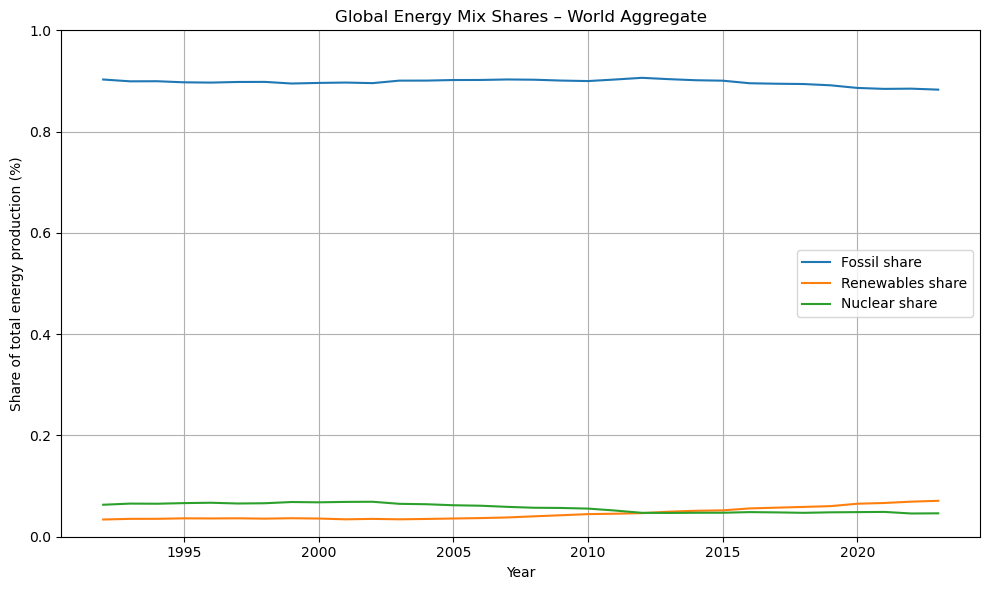

In [23]:
# Ensure derived energy components exist; if not, recompute quickly
for col in ["fossil_energy", "nuclear_energy", "renewables_energy"]:
    if col not in world.columns:
        raise ValueError(f"Column {col} missing in world data. Recreate features first.")

total = world[col_total]

world["fossil_share_world"]     = np.where(total > 0, world["fossil_energy"]     / total, np.nan)
world["nuclear_share_world"]    = np.where(total > 0, world["nuclear_energy"]    / total, np.nan)
world["renewables_share_world"] = np.where(total > 0, world["renewables_energy"] / total, np.nan)

plt.figure()
plt.plot(world["year"], world["fossil_share_world"],     label="Fossil share")
plt.plot(world["year"], world["renewables_share_world"], label="Renewables share")
plt.plot(world["year"], world["nuclear_share_world"],    label="Nuclear share")
plt.title("Global Energy Mix Shares – World Aggregate")
plt.xlabel("Year")
plt.ylabel("Share of total energy production (%)")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


### 16.3 Global CO₂ intensity per unit of energy

In the next step we compute a simple **global CO₂ intensity** indicator for the World aggregate:

> CO₂ intensity = CO₂ emissions / total energy production.

This shows whether the world as a whole is emitting more or less CO₂ per unit of energy over time. A declining path would be consistent with cleaner technologies or greater efficiency; a flat or increasing path would indicate that decarbonisation is limited at the global level.

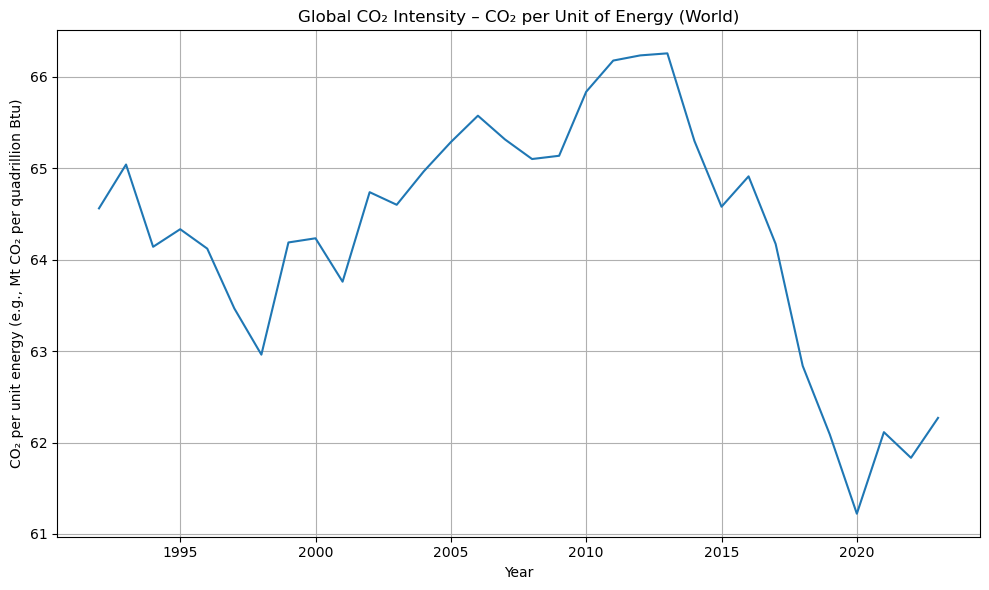

In [24]:
world["co2_per_energy_world"] = np.where(
    world[col_total] > 0,
    world[col_co2] / world[col_total],
    np.nan
)

plt.figure()
plt.plot(world["year"], world["co2_per_energy_world"])
plt.title("Global CO₂ Intensity – CO₂ per Unit of Energy (World)")
plt.xlabel("Year")
plt.ylabel("CO₂ per unit energy (e.g., Mt CO₂ per quadrillion Btu)")
plt.tight_layout()
plt.show()


### 16.4 From global aggregates back to the country panel

After providing global context, we explicitly return to the **country-level panel dataset**. From this point onward:

- the World aggregate is excluded,
- all descriptive statistics and plots refer to **countries only**, and
- the unit of analysis is consistently the **country–year** observation.

This separation avoids treating World as if it were a country and keeps the empirical analysis aligned with the panel regression design.

In [25]:
# From this point on: use countries ONLY
panel_countries = countries.copy()

print("Final country-only panel shape:", panel_countries.shape)
print("Unique regions:", sorted(panel_countries["region"].unique()))


Final country-only panel shape: (1024, 32)
Unique regions: ['Algeria', 'Australia', 'Bangladesh', 'Brazil', 'Canada', 'China', 'Ethiopia', 'France', 'Germany', 'India', 'Indonesia', 'Iran', 'Iraq', 'Italy', 'Japan', 'Kazakhstan', 'Kuwait', 'Mexico', 'Nigeria', 'Norway', 'Pakistan', 'Philippines', 'Qatar', 'Russia', 'Saudi Arabia', 'South Africa', 'South Korea', 'Thailand', 'Turkiye', 'United Arab Emirates', 'United Kingdom', 'United States']


---

The remaining EDA subsections work exclusively with the country-only panel and, where relevant, focus on the **Top 20 CO₂-emitting countries**. This mirrors the empirical focus of the thesis on the largest contributors to global emissions.

### 16.5 Cross-country distribution of CO₂ emissions and Top 20 selection

The next code cell computes the long-run average CO₂ emissions for each country (1992–2023) and identifies the **Top 20 CO₂-emitting countries** in the sample. A bar chart then visualises the average emissions for these countries.

This step shows that emissions are highly concentrated among a relatively small set of countries and provides a data-driven justification for focusing on the Top 20 in the subsequent visual analysis and econometric modelling.

In [26]:
# Country-only panel (World already excluded earlier)
countries = panel[panel["region"] != "World"].copy()

# Compute average CO2 emissions per country
avg_co2 = (
    countries
    .groupby("region")["CO2 emissions"]
    .mean()
    .sort_values(ascending=False)
)

# Select top 20
top20_countries = avg_co2.head(20)
top20_countries


region
China             7192.697834
United States     5441.301727
Russia            1693.897699
India             1494.572088
Japan             1192.393967
Germany            823.502435
Canada             546.132697
South Korea        539.527276
United Kingdom     510.546496
Iran               470.593581
South Africa       430.023806
Saudi Arabia       429.567603
Mexico             414.575287
Italy              402.458490
Brazil             379.922511
France             376.656563
Indonesia          373.410084
Australia          360.695737
Turkiye            269.141437
Kazakhstan         241.198368
Name: CO2 emissions, dtype: float64

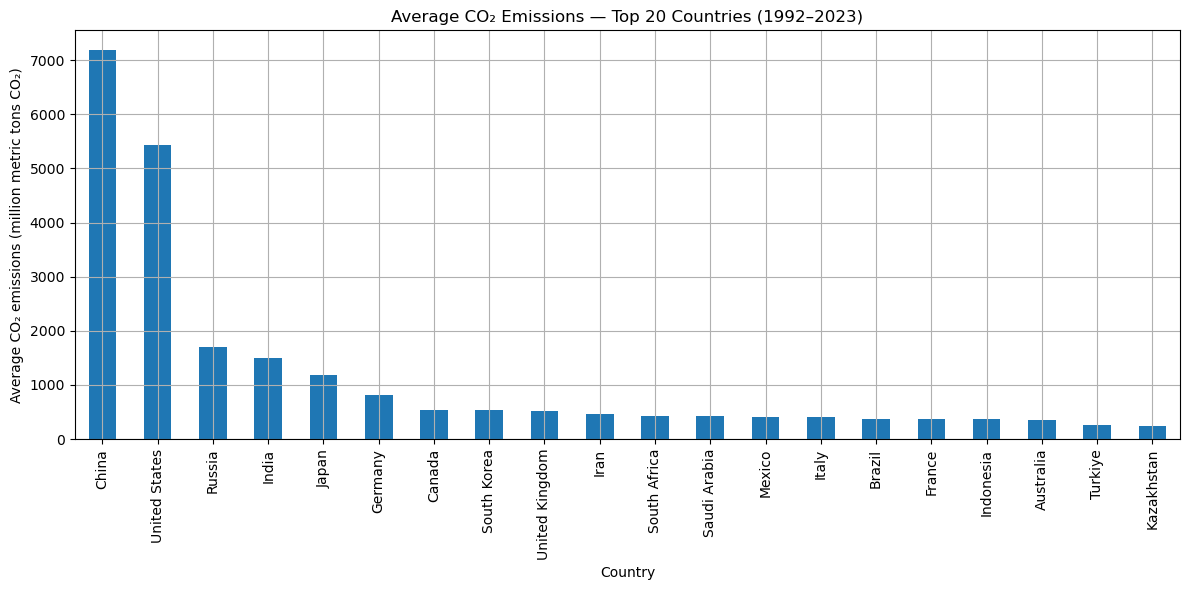

In [27]:
plt.figure(figsize=(12, 6))
top20_countries.plot(kind="bar")
plt.title("Average CO₂ Emissions — Top 20 Countries (1992–2023)")
plt.xlabel("Country")
plt.ylabel("Average CO₂ emissions (million metric tons CO₂)")
plt.tight_layout()
plt.show()


### 16.6 Cross-country distribution of total energy production and Top 20 selection

This subsection mirrors the CO₂-based analysis by examining the cross-country distribution of total energy production. Using the country-level panel, we compute the long-run average total energy production for each country over the period 1992–2023.

A bar chart is used to visualise average total energy production across countries and to identify the Top 20 total energy–producing countries in the sample. This distribution highlights the strong concentration of global energy production among a limited number of countries.

Identifying the Top 20 energy producers serves two purposes. First, it confirms that a small subset of countries dominates global energy supply, reinforcing their relevance for the analysis. Second, it allows comparison between the sets of top energy producers and top CO₂ emitters, which helps assess the extent to which high emissions are driven by energy scale versus energy composition.

This step provides a complementary, scale-based justification for focusing on a restricted group of countries in the subsequent exploratory analysis and econometric modelling.

In [28]:
import matplotlib.pyplot as plt

# Ensure we are working with country-only data
countries = panel[panel["region"] != "World"].copy()

# Compute long-run average total energy production (1992–2023)
avg_energy = (
    countries
    .groupby("region")["total energy production"]
    .mean()
    .sort_values(ascending=False)
)

# Select Top 20 energy-producing countries
top20_energy = avg_energy.head(20)

# Display Top 20 list (useful for verification / appendix)
top20_energy


region
United States           76.802562
China                   75.956590
Russia                  51.411671
Saudi Arabia            24.341276
Canada                  16.538392
Iran                    13.127619
Australia               12.191334
India                   11.936790
Indonesia               10.950149
Norway                   8.703997
United Arab Emirates     8.311449
Mexico                   8.140989
United Kingdom           7.644050
Brazil                   6.690571
Algeria                  6.363527
Qatar                    5.932187
Kazakhstan               5.840665
Iraq                     5.713102
Kuwait                   5.607426
Nigeria                  5.511644
Name: total energy production, dtype: float64

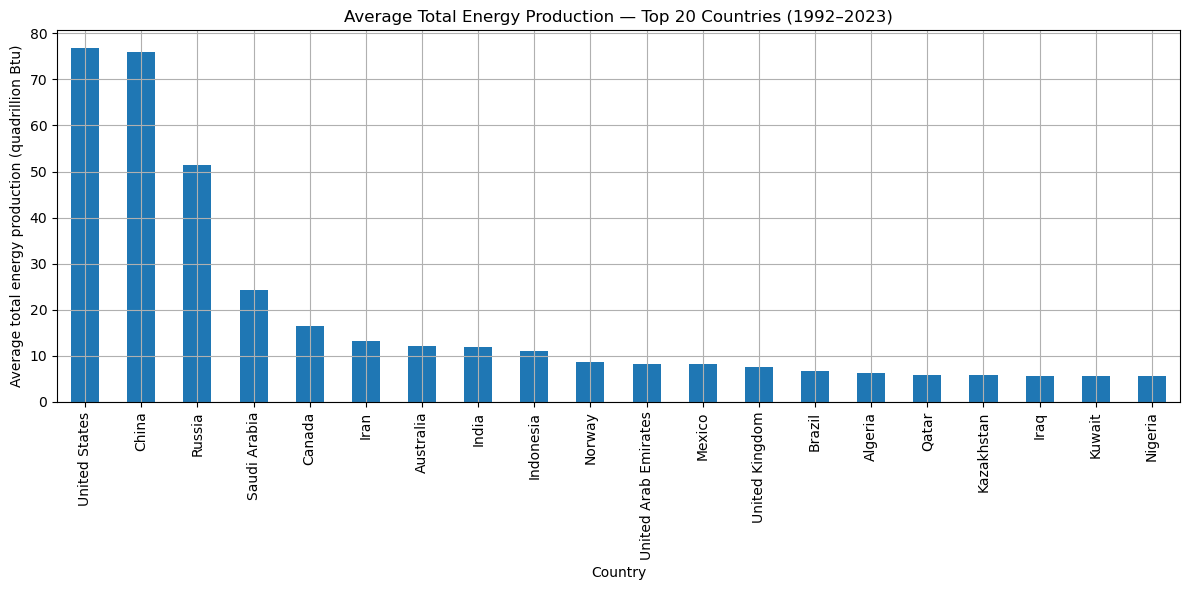

In [29]:
plt.figure(figsize=(12, 6))

top20_energy.plot(kind="bar")

plt.title("Average Total Energy Production — Top 20 Countries (1992–2023)")
plt.xlabel("Country")
plt.ylabel("Average total energy production (quadrillion Btu)")
plt.tight_layout()
plt.show()


### 16.7 Energy mix of the Top 20 CO₂-emitting countries

For the Top 20 CO₂-emitting countries, we compute their **average energy mix** over the sample period and display it as stacked bars combining:

- fossil energy share,
- renewables share, and
- nuclear share.

This figure makes cross-country differences in energy composition explicit. High-emitting countries tend to have a high fossil share, whereas countries with substantial nuclear or renewable components typically show lower fossil dependence. This supports the idea that **energy composition** is an important driver of CO₂ emissions, beyond total energy use alone.

<Figure size 1200x700 with 0 Axes>

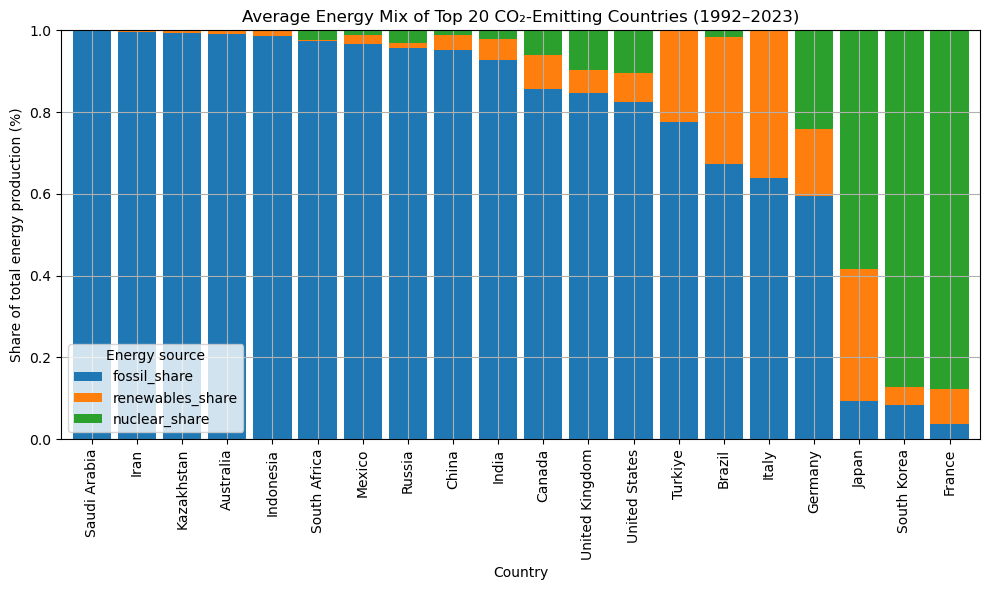

In [30]:
# Ensure we are using country-only data
countries = panel[panel["region"] != "World"].copy()

# Top 20 CO2 emitters based on long-run average
avg_co2 = (
    countries
    .groupby("region")["CO2 emissions"]
    .mean()
    .sort_values(ascending=False)
)

top20 = avg_co2.head(20).index.tolist()
top20
energy_mix_top20 = (
    countries[countries["region"].isin(top20)]
    .groupby("region")[[
        "fossil_share",
        "renewables_share",
        "nuclear_share"
    ]]
    .mean()
)

# Sort by fossil dependence (makes plot easier to read)
energy_mix_top20 = energy_mix_top20.sort_values("fossil_share", ascending=False)

energy_mix_top20.head()
plt.figure(figsize=(12, 7))

energy_mix_top20.plot(
    kind="bar",
    stacked=True,
    width=0.85
)

plt.title("Average Energy Mix of Top 20 CO₂-Emitting Countries (1992–2023)")
plt.xlabel("Country")
plt.ylabel("Share of total energy production (%)")
plt.ylim(0, 1)

plt.legend(
    title="Energy source",
    loc="lower left"
)

plt.tight_layout()
plt.show()



### 16.8 CO₂ intensity: per capita and per unit of energy

The following cells construct and visualise two intensity-based indicators for the Top 20 countries:

1. **CO₂ per capita** – CO₂ emissions scaled by population, and  
2. **CO₂ per unit of energy** – CO₂ emissions divided by total energy production.

These measures help differentiate between countries that emit a lot because they are large (population or energy scale) and those that are genuinely more carbon-intensive relative to their energy systems. The plots motivate the inclusion of **population** and **energy scale** controls in the regression models.

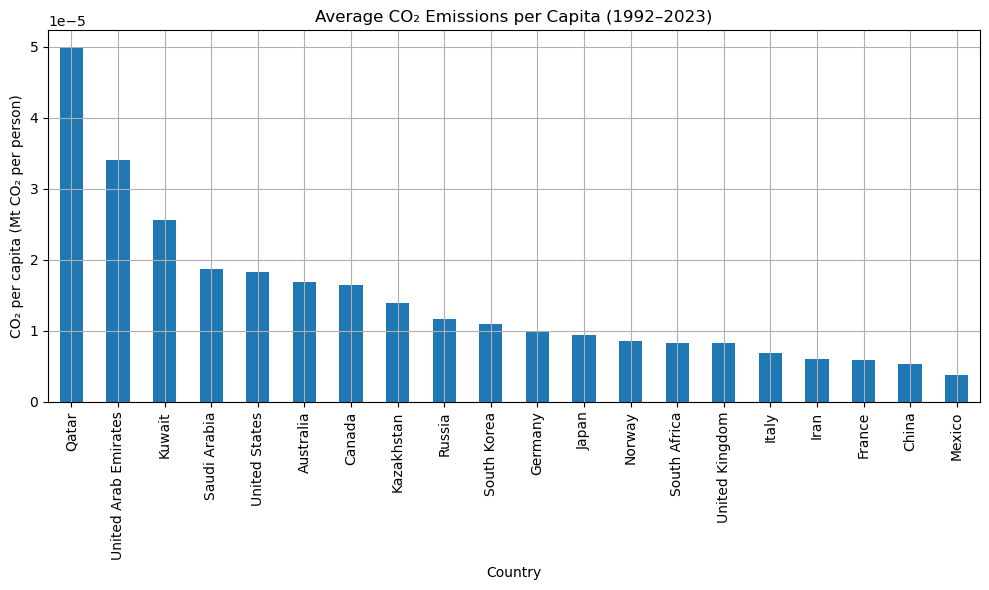

In [31]:
avg_co2_pc = (
    countries
    .groupby("region")["co2_per_capita"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure()
avg_co2_pc.head(20).plot(kind="bar")
plt.title("Average CO₂ Emissions per Capita (1992–2023)")
plt.ylabel("CO₂ per capita (Mt CO₂ per person)")
plt.xlabel("Country")
plt.tight_layout()
plt.show()


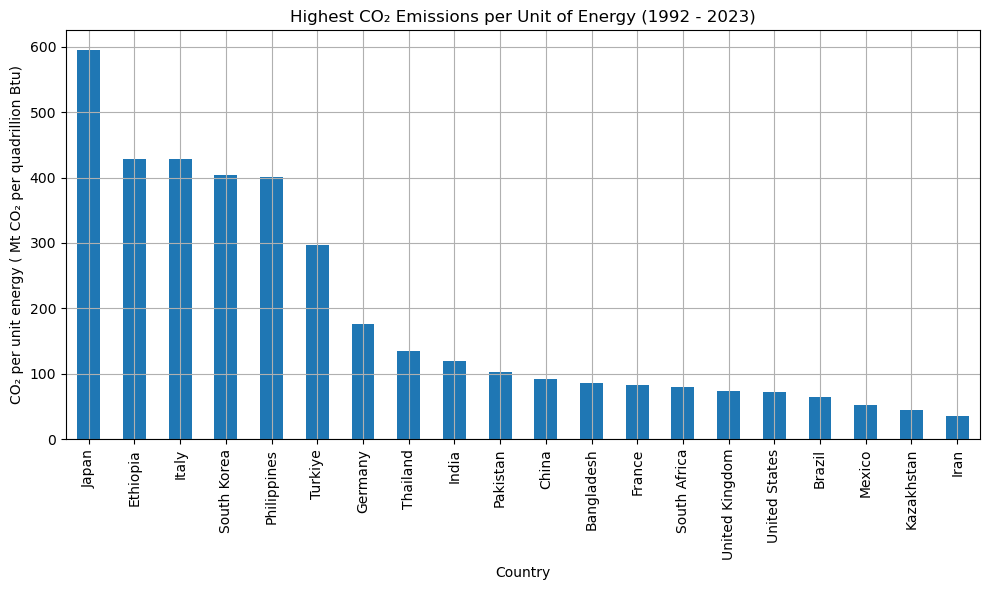

In [32]:
avg_intensity = (
    countries
    .groupby("region")["co2_per_energy"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure()
avg_intensity.head(20).plot(kind="bar")
plt.title("Highest CO₂ Emissions per Unit of Energy (1992 - 2023)")
plt.xlabel("Country")
plt.ylabel("CO₂ per unit energy ( Mt CO₂ per quadrillion Btu)")
plt.tight_layout()
plt.show()


### 16.9 Correlation with CO₂ emissions

Next, we compute and display correlations between `ln(CO₂)` and a selected set of explanatory variables, including:

- log fossil, renewable, and nuclear energy production (scale effects),
- energy shares for fossil, renewables, and nuclear (composition effects), and
- log GDP and log population (economic and demographic scale).

The resulting correlation table and bar chart are **descriptive tools**. They do not establish causality, but they help to:

- identify broad relationships between CO₂ emissions and energy variables,
- highlight the importance of separating scale from composition, and
- detect potential multicollinearity issues that must be addressed in the panel regression specification.

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Country-only data
countries = panel[panel["region"] != "World"].copy()

# Identify Top 20 CO2 emitters (long-run average)
avg_co2 = (
    countries
    .groupby("region")["CO2 emissions"]
    .mean()
    .sort_values(ascending=False)
)

top20 = avg_co2.head(20).index.tolist()

# Filter data to Top 20 countries
top20_df = countries[countries["region"].isin(top20)].copy()

print("Top 20 countries included:", top20)


Top 20 countries included: ['China', 'United States', 'Russia', 'India', 'Japan', 'Germany', 'Canada', 'South Korea', 'United Kingdom', 'Iran', 'South Africa', 'Saudi Arabia', 'Mexico', 'Italy', 'Brazil', 'France', 'Indonesia', 'Australia', 'Turkiye', 'Kazakhstan']


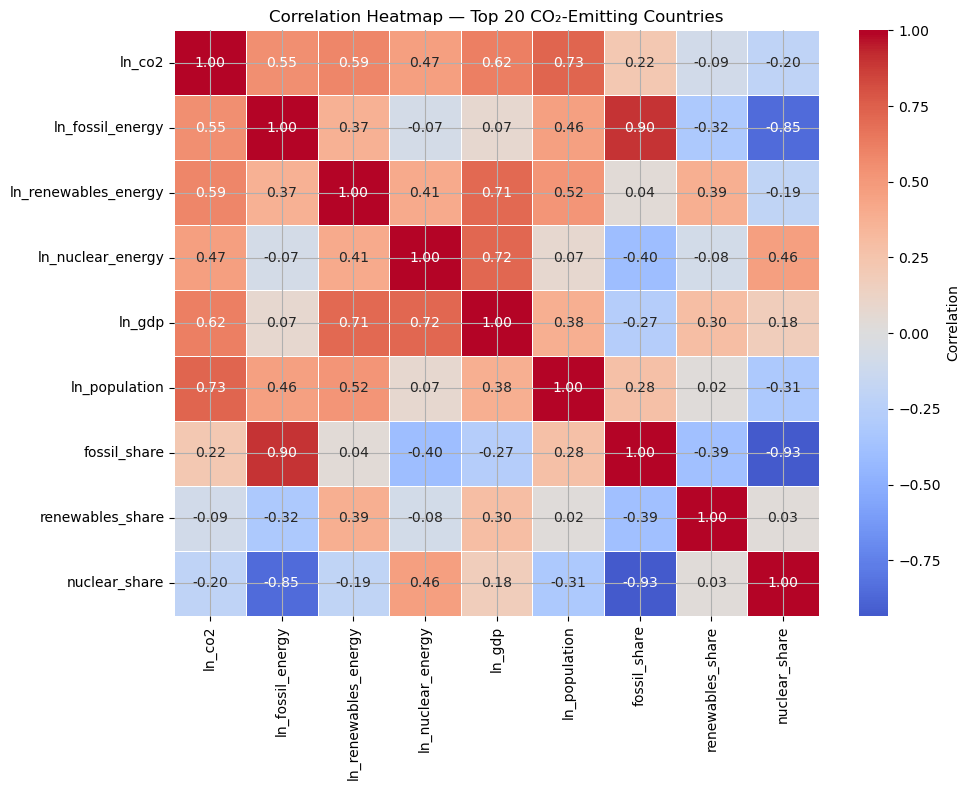

In [34]:
corr_vars = [
    "ln_co2",
    "ln_fossil_energy",
    "ln_renewables_energy",
    "ln_nuclear_energy",
    "ln_gdp",
    "ln_population",
    "fossil_share",
    "renewables_share",
    "nuclear_share"
]

corr_data = top20_df[corr_vars].dropna()
corr_matrix = corr_data.corr()
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"}
)

plt.title("Correlation Heatmap — Top 20 CO₂-Emitting Countries")
plt.tight_layout()
plt.show()


### 16.10 Visualising correlation structure and log–log relationships

Finally, we complement the scalar correlation measures with:

- a **correlation heatmap**, summarising the joint correlation structure among log variables and energy shares, and
- **pairwise log–log scatter plots** with fitted regression lines between `ln(CO₂)` and key energy variables.

The heatmap provides a compact overview of how the main variables co-move, while the scatter plots reveal the shape and dispersion of the relationships. Working in logs reduces skewness and allows the patterns to be interpreted in terms of elasticities (percentage changes). Together, these visualisations provide an intuitive bridge from descriptive analysis to the fixed-effects panel regressions used in the empirical part of the thesis.

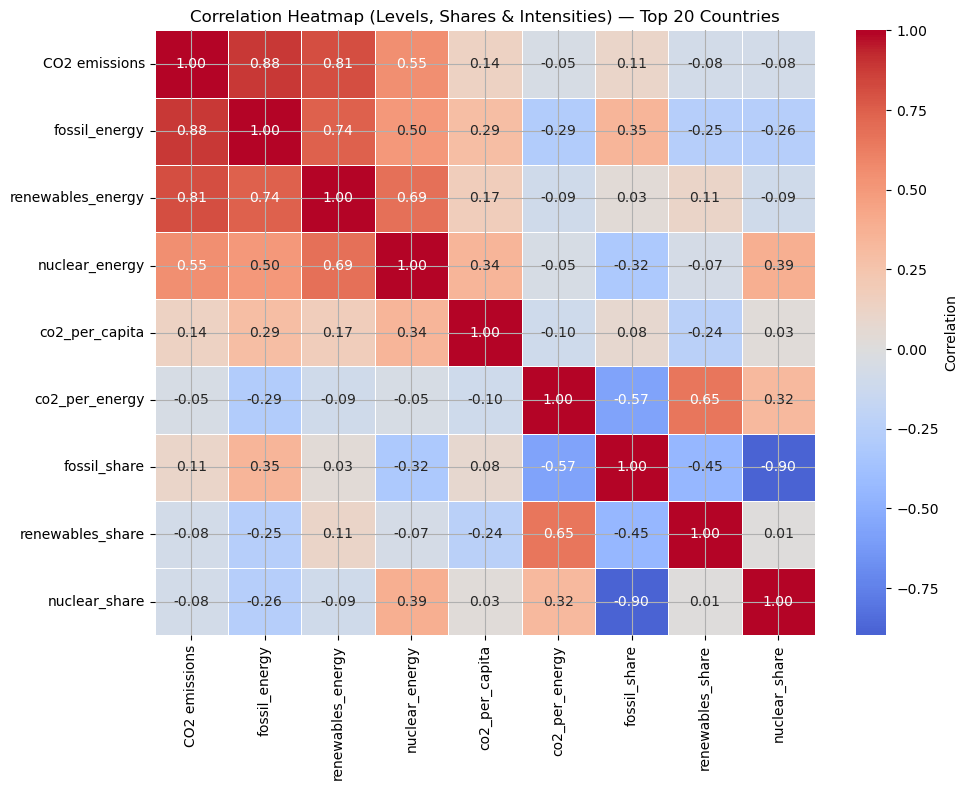

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

vars_no_log = [
    "CO2 emissions",
    "fossil_energy",
    "renewables_energy",
    "nuclear_energy",
    "co2_per_capita",
    "co2_per_energy",
    "fossil_share",
    "renewables_share",
    "nuclear_share"
]

heat_data = top20_df[vars_no_log].dropna()
corr_no_log = heat_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_no_log,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"}
)
plt.title("Correlation Heatmap (Levels, Shares & Intensities) — Top 20 Countries")
plt.tight_layout()
plt.show()


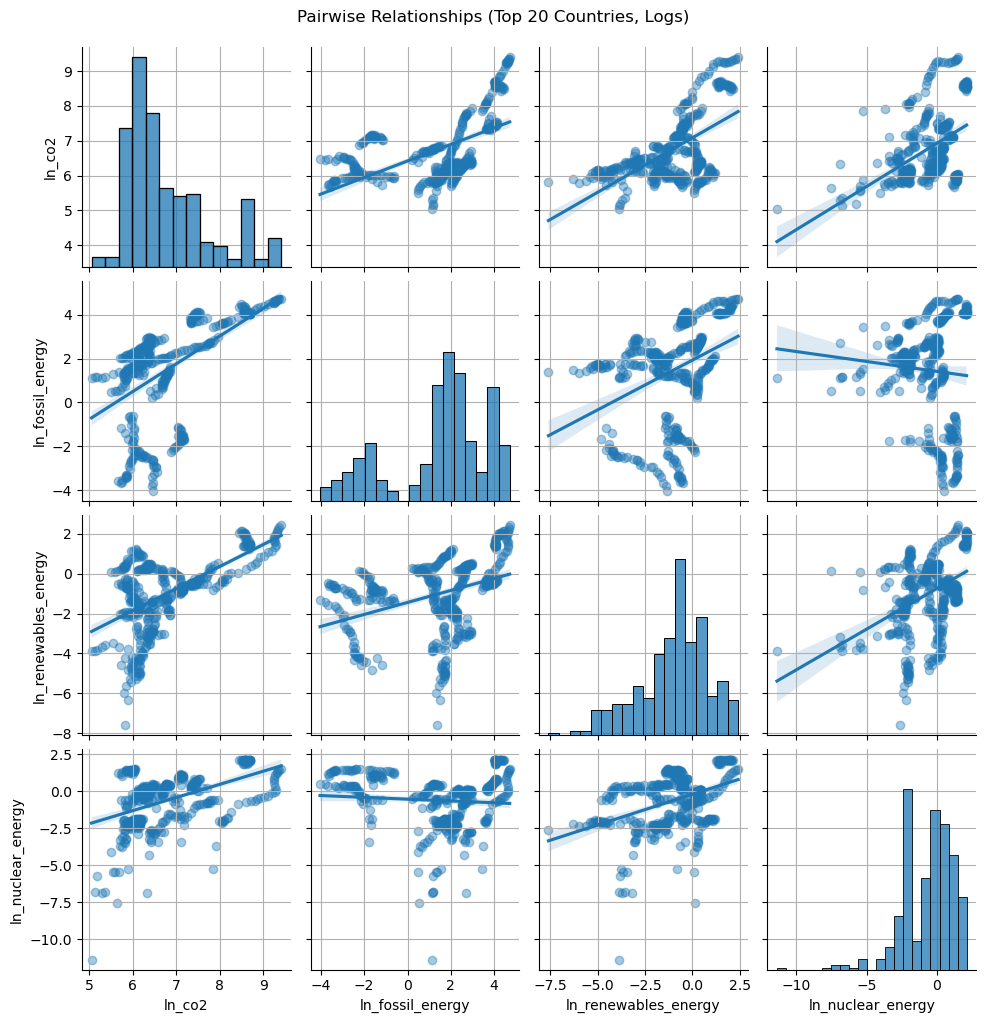

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

vars_for_pairs = [
    "ln_co2",
    "ln_fossil_energy",
    "ln_renewables_energy",
    "ln_nuclear_energy"
]

sns.pairplot(
    top20_df[vars_for_pairs].dropna(),
    kind="reg",
    plot_kws={"scatter_kws": {"alpha": 0.4}}
)

plt.suptitle("Pairwise Relationships (Top 20 Countries, Logs)", y=1.02)
plt.show()


## 17. Regression Analysis

This section investigates the empirical relationship between energy production, energy composition, and CO₂ emissions across countries using econometric regression models. The objective is to formally test the hypotheses derived from the research question:

> *How do fossil, renewable, and nuclear energy production influence CO₂ emissions in the world’s top energy-producing countries?*

The analysis is conducted using pooled Ordinary Least Squares (OLS) regressions with heteroskedasticity-robust (HC1) standard errors. All models are estimated on an unbalanced country–year panel covering **33 countries over the period 1992–2023**, excluding the aggregate *World* observation to avoid mechanical correlations.

### 17.1 Model specification and estimation strategy

Two complementary regression models are estimated.

First, a **baseline scale model** is used to quantify the role of fossil energy use, economic activity, and population size in explaining CO₂ emissions. This model captures the traditional scale effects emphasized in the environmental economics literature.

Second, an extended **scale and composition model** is estimated, which decomposes energy effects into overall energy scale and energy mix components. This allows for a direct assessment of whether a higher share of renewable or nuclear energy is associated with lower CO₂ emissions, conditional on total energy production.

All variables entering the regressions are transformed into natural logarithms where appropriate. Logarithmic specifications allow coefficients to be interpreted as elasticities and reduce skewness in the underlying distributions.

### 17.2 Baseline scale model (H1, H4, H5)

The baseline model is specified as:

\[
\ln(\text{CO}_2_{it}) = \alpha + \beta_1 \ln(\text{FossilEnergy}_{it}) + \beta_2 \ln(\text{GDP}_{it}) + \beta_3 \ln(\text{Population}_{it}) + \varepsilon_{it}
\]

This model directly tests the following hypotheses:

- **H1:** Fossil energy production is positively associated with CO₂ emissions  
- **H4:** GDP is positively associated with CO₂ emissions  
- **H5:** Population is positively associated with CO₂ emissions  

The estimated coefficients represent elasticities, indicating the percentage change in CO₂ emissions associated with a 1% change in the respective explanatory variable.

### 17.3 Scale and composition model (H1–H5)

To assess the role of energy mix in addition to energy scale, the second model is specified as:

\[
\ln(\text{CO}_2_{it}) = \alpha + \beta_1 \ln(\text{TotalEnergy}_{it}) + \beta_2 \text{RenewablesShare}_{it} + \beta_3 \text{NuclearShare}_{it} + \beta_4 \ln(\text{GDP}_{it}) + \beta_5 \ln(\text{Population}_{it}) + \varepsilon_{it}
\]

This specification allows total energy production and energy composition effects to be disentangled. It directly tests:

- **H2:** Renewable energy production is negatively associated with CO₂ emissions  
- **H3:** Nuclear energy production is negatively associated with CO₂ emissions  

while continuing to control for economic scale and population size.

The inclusion of energy shares rather than absolute levels enables a cleaner interpretation of substitution effects within the energy mix.

### 17.4 Estimation details and robustness considerations

All regressions are estimated using pooled OLS with **HC1 heteroskedasticity-robust standard errors**, addressing potential heteroskedasticity across countries and over time.

Observations with missing values in any regression variable are excluded on a model-by-model basis. The sample size therefore remains consistent across models within each specification.

Although the panel structure of the data could motivate fixed-effects estimation, pooled OLS is intentionally employed at this stage to preserve cross-country variation and maintain consistency with the descriptive and exploratory analysis. Fixed-effects extensions are discussed as a potential robustness check in the concluding section.

### 17.5 Interpretation strategy

Regression results are interpreted along three dimensions:

1. **Statistical significance** (p-values and confidence intervals)  
2. **Economic magnitude** (elasticities and marginal effects)  
3. **Consistency with theoretical expectations and prior literature**

Special attention is paid to the distinction between **energy scale effects** and **energy composition effects**, as this distinction is central to understanding why renewable and nuclear energy expansion may coexist with rising emissions in large, fast-growing economies.


In [37]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Load final panel
df = pd.read_csv("dataset/panel_33countries_1992_2023_features.csv")

# Keep only countries (drop World)
df = df[df["region"] != "World"].copy()

# Ensure key variables are numeric
num_cols = [
    "ln_co2",
    "ln_fossil_energy",
    "ln_gdp",
    "ln_population",
    "total energy production",
    "renewables_share",
    "nuclear_share"
]

for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Create ln_total_energy if not already present
if "ln_total_energy" not in df.columns:
    df["ln_total_energy"] = np.log(df["total energy production"])

# Drop any rows with missing values in variables used for regressions
df = df.dropna(subset=[
    "ln_co2",
    "ln_fossil_energy",
    "ln_gdp",
    "ln_population",
    "ln_total_energy",
    "renewables_share",
    "nuclear_share"
]).reset_index(drop=True)

print(df[["region", "year", "ln_co2", "ln_fossil_energy", "ln_gdp", "ln_population"]].head())
print("Final regression sample shape:", df.shape)

    region  year    ln_co2  ln_fossil_energy     ln_gdp  ln_population
0  Algeria  1992  4.309328          1.589625  24.594532      17.097495
1  Algeria  1993  4.221331          1.569153  24.634200      17.121556
2  Algeria  1994  4.253838          1.536208  24.473785      17.143681
3  Algeria  1995  4.286848          1.602824  24.455308      17.164368
4  Algeria  1996  4.262858          1.651017  24.572169      17.183945
Final regression sample shape: (994, 32)


In [38]:
# 17.1 Baseline scale model (H1, H4, H5)

y = df["ln_co2"].astype("float64")

X1 = df[[
    "ln_fossil_energy",
    "ln_gdp",
    "ln_population"
]].astype("float64")

X1 = sm.add_constant(X1)

model1 = sm.OLS(y.values, X1.values).fit(cov_type="HC1")
print(model1.summary())

# Create labeled coefficient table
model1_table = pd.DataFrame({
    "Variable": ["Constant", "ln(Fossil energy)", "ln(GDP)", "ln(Population)"],
    "Coefficient": model1.params,
    "Std. Error": model1.bse,
    "p-value": model1.pvalues
})

model1_table


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.766
Model:                            OLS   Adj. R-squared:                  0.765
Method:                 Least Squares   F-statistic:                     867.0
Date:                Fri, 27 Feb 2026   Prob (F-statistic):          2.13e-276
Time:                        18:26:29   Log-Likelihood:                -930.51
No. Observations:                 994   AIC:                             1869.
Df Residuals:                     990   BIC:                             1889.
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -12.2590      0.406    -30.185      0.0

,Variable,Coefficient,Std. Error,p-value
0,Constant,-12.259005,0.406128,3.714483e-200
1,ln(Fossil energy),0.187299,0.010593,5.749405e-70
2,ln(GDP),0.514531,0.018906,4.236063e-163
3,ln(Population),0.218699,0.017583,1.624373e-35


In [39]:
# 17.2 Scale + composition model (H1–H5, main specification)

# Dependent variable (same as before)
y = df["ln_co2"].astype("float64")

# Explanatory variables: total energy scale, energy shares, GDP, population
X2 = df[[
    "ln_total_energy",
    "renewables_share",
    "nuclear_share",
    "ln_gdp",
    "ln_population"
]].astype("float64")

X2 = sm.add_constant(X2)

y2 = y.values
X2_arr = X2.values

model2 = sm.OLS(y2, X2_arr).fit(cov_type="HC1")
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.807
Model:                            OLS   Adj. R-squared:                  0.806
Method:                 Least Squares   F-statistic:                     921.1
Date:                Fri, 27 Feb 2026   Prob (F-statistic):               0.00
Time:                        18:26:29   Log-Likelihood:                -833.76
No. Observations:                 994   AIC:                             1680.
Df Residuals:                     988   BIC:                             1709.
Df Model:                           5                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -8.1343      0.544    -14.951      0.0

In [40]:
# Create labeled coefficient table
model2_table = pd.DataFrame({
    "Variable": [
        "Constant",
        "ln(Total energy)",
        "Renewables share",
        "Nuclear share",
        "ln(GDP)",
        "ln(Population)"
    ],
    "Coefficient": model2.params,
    "Std. Error": model2.bse,
    "p-value": model2.pvalues
})

model2_table

,Variable,Coefficient,Std. Error,p-value
0,Constant,-8.134346,0.544066,1.533536e-50
1,ln(Total energy),0.433324,0.022216,9.862273e-85
2,Renewables share,0.938731,0.226110,3.300869e-05
3,Nuclear share,0.660541,0.102754,1.289659e-10
4,ln(GDP),0.302755,0.026235,8.274375e-31
5,ln(Population),0.271704,0.016138,1.325625e-63


# Conclusion

## Summary of Findings

This study examined the relationship between energy production structure and CO₂ emissions using a balanced panel dataset of major energy-producing countries from 1992–2023. By combining scale variables (total energy production, GDP, population) with composition variables (renewable and nuclear energy shares), the analysis distinguishes between **energy demand effects** and **energy mix effects**.

The empirical results lead to the following key conclusions:

### 1. Energy Scale is the Dominant Driver of Emissions

Across all model specifications, total energy production (or fossil energy production in the baseline model) is the strongest and most statistically significant predictor of CO₂ emissions.

- A 1% increase in fossil energy production is associated with a proportional increase in CO₂ emissions.
- GDP and population growth also contribute positively to emissions, reflecting increased production, consumption, and energy demand.

This confirms that **economic and demographic expansion continue to exert upward pressure on emissions**, primarily through higher energy use.

---

### 2. Composition Effects Exist but Are Secondary

When separating total energy scale from energy mix composition:

- Renewable and nuclear shares are associated with lower carbon intensity.
- However, their direct impact on total CO₂ emissions is limited when overall energy demand continues to grow.
- In several high-emission countries, renewable expansion occurs alongside fossil fuel expansion rather than replacing it.

This suggests that **energy transition efforts may reduce emissions intensity**, but do not automatically reduce total emissions unless accompanied by structural reductions in fossil energy use.

---

### 3. Evidence of Partial Decoupling

Descriptive analysis indicates that:

- Global CO₂ intensity (emissions per unit of energy) has declined over time.
- Total energy production and total emissions, however, continue to increase.

This reflects **relative decoupling** (improving efficiency), but not full decoupling (absolute emission reduction).

---

## Interpretation in the Context of the Hypotheses

- **H1 (Fossil energy positively associated with CO₂)** — Strongly supported.
- **H2 (Renewable energy negatively associated with CO₂)** — Partially supported. Renewables are linked to lower carbon intensity, but do not automatically reduce total emissions in high-growth contexts.
- **H3 (Nuclear energy negatively associated with CO₂)** — Moderately supported through intensity effects, though masked by overall energy demand growth.
- **H4 & H5 (GDP and Population positive effects)** — Supported.

Overall, the results emphasize that **energy scale effects dominate composition effects**.

---

## Policy Implications

The findings suggest that:

1. Expanding renewable capacity alone is insufficient if total energy demand continues to rise rapidly.
2. Policies must prioritize:
   - Fossil fuel substitution rather than parallel expansion,
   - Energy efficiency improvements,
   - Structural transformation toward low-carbon production systems.
3. Managing demand growth may be as important as altering supply composition.

A balanced strategy combining renewable expansion, fossil fuel phase-out, and efficiency improvements is necessary for meaningful emissions reduction.

---

## Limitations and Future Scope

This study relies on pooled OLS estimation, which does not fully account for unobserved country-specific heterogeneity or long-run dynamic adjustments. Future research should consider:

- Fixed-effects and dynamic panel models,
- Lagged energy transition effects,
- Sector-specific emission analysis,
- Policy evaluation frameworks,
- Non-linear and interaction models.

---

## Final Statement

The empirical evidence demonstrates that while cleaner energy sources contribute to improved emission efficiency, **total energy demand remains the central determinant of CO₂ emissions**. Sustainable climate policy therefore requires not only cleaner energy production, but also structural and behavioral changes that limit carbon-intensive growth pathways.